### Time Series Forecasting Assignments: ARIMA, SARIMA, Prophet



In [11]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [12]:
# Airline Passengers data (monthly totals in thousands, 1949-1960)
values = [
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432
]

dates = pd.date_range(start='1949-01-01', periods=len(values), freq='MS')
df = pd.DataFrame({'Month': dates, 'Passengers': values}).set_index('Month')
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [13]:
train = df.iloc[:-12].copy()
test = df.iloc[-12:].copy()

# Set frequency explicitly to avoid statsmodels warning
train.index.freq = 'MS'

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Train period: {train.index.min().date()} to {train.index.max().date()}')
print(f'Test period: {test.index.min().date()} to {test.index.max().date()}')

Train shape: (132, 1)
Test shape: (12, 1)
Train period: 1949-01-01 to 1959-12-01
Test period: 1960-01-01 to 1960-12-01


## Assignment 1: ARIMA Modeling

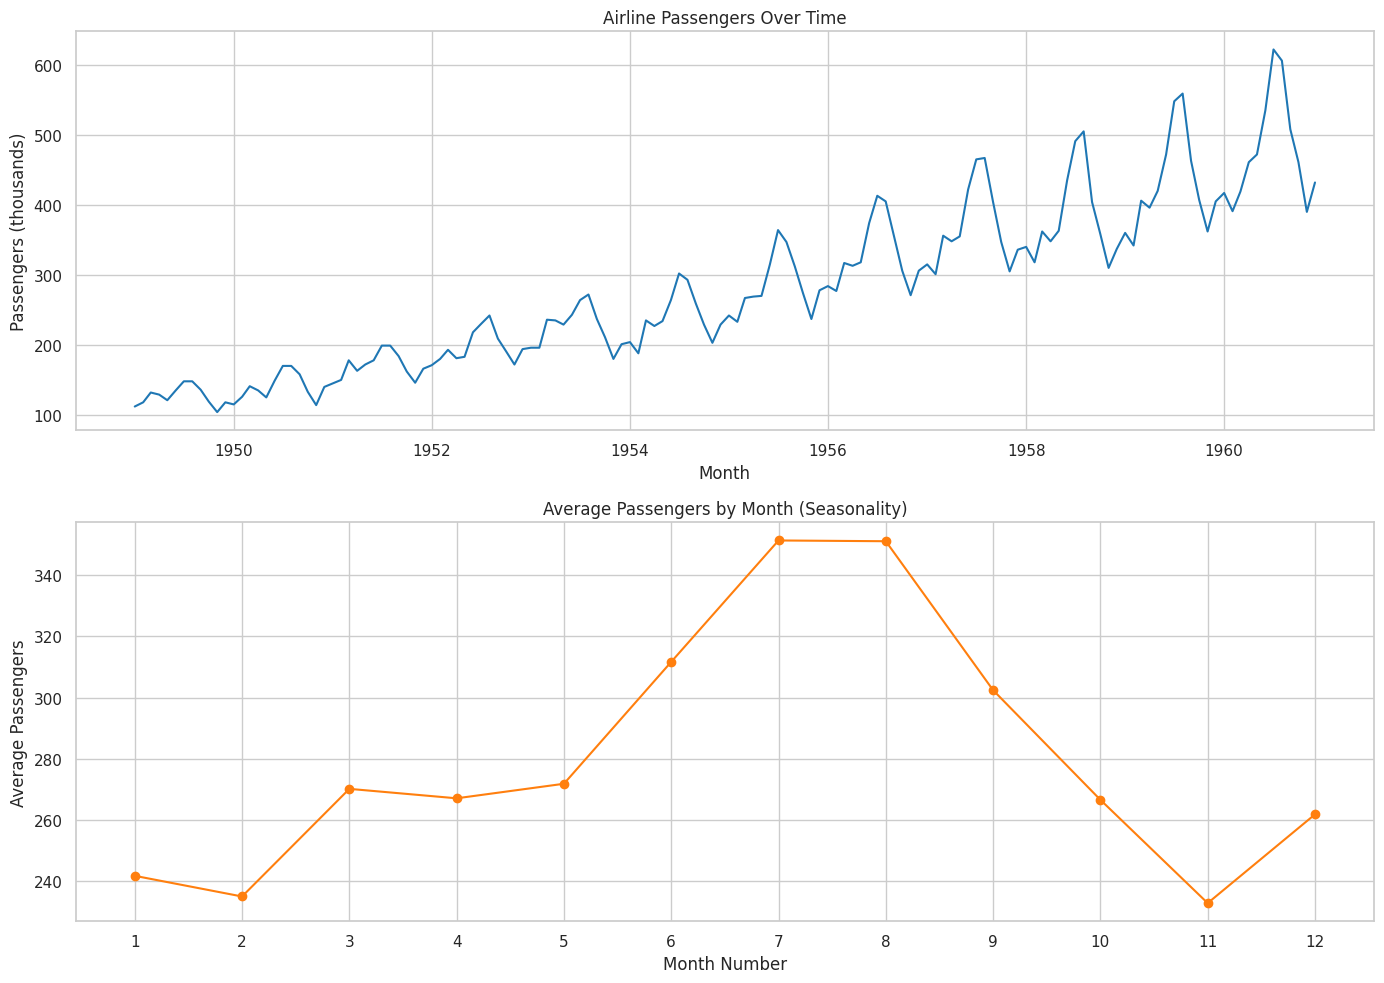

In [14]:
# 1) Visualize data (trend & seasonality)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df.index, df['Passengers'], color='tab:blue')
axes[0].set_title('Airline Passengers Over Time')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Passengers (thousands)')

monthly_avg = df.groupby(df.index.month)['Passengers'].mean()
axes[1].plot(monthly_avg.index, monthly_avg.values, marker='o', color='tab:orange')
axes[1].set_title('Average Passengers by Month (Seasonality)')
axes[1].set_xlabel('Month Number')
axes[1].set_ylabel('Average Passengers')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [15]:
# 2) Check stationarity using ADF test
def adf_test(series, name='Series'):
    result = adfuller(series.dropna())
    print(f'ADF Test for {name}')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    for key, value in result[4].items():
        print(f'Critical Value ({key}): {value:.4f}')
    print('Stationary' if result[1] < 0.05 else 'Non-stationary')
    return result[1]

p_value_original = adf_test(train['Passengers'], 'Original Train Series')

ADF Test for Original Train Series
ADF Statistic: 0.8880
p-value: 0.9929
Critical Value (1%): -3.4870
Critical Value (5%): -2.8864
Critical Value (10%): -2.5800
Non-stationary


Selected differencing order d = 2


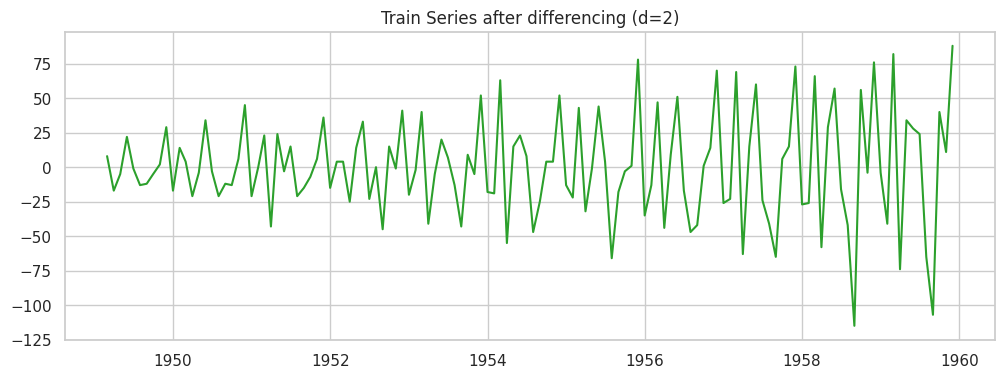

ADF Test for Differenced Series (d=2)
ADF Statistic: -14.2529
p-value: 0.0000
Critical Value (1%): -3.4870
Critical Value (5%): -2.8864
Critical Value (10%): -2.5800
Stationary


np.float64(1.470790955589313e-26)

In [16]:
# 3) Apply differencing if required
d = 0
diff_series = train['Passengers'].copy()

while d < 2:
    pval = adfuller(diff_series.dropna())[1]
    if pval < 0.05:
        break
    d += 1
    diff_series = diff_series.diff().dropna()

print(f'Selected differencing order d = {d}')

plt.figure(figsize=(12, 4))
plt.plot(diff_series.index, diff_series, color='tab:green')
plt.title(f'Train Series after differencing (d={d})')
plt.show()

adf_test(diff_series, f'Differenced Series (d={d})')

In [17]:
# 4) Fit ARIMA model (small AIC-based search for p, q)
best_aic = np.inf
best_order = None
best_arima_model = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train['Passengers'], order=(p, d, q))
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
                best_arima_model = fitted
        except Exception:
            continue

print(f'Best ARIMA order: {best_order}, AIC: {best_aic:.2f}')
print(best_arima_model.summary())

Best ARIMA order: (1, 2, 2), AIC: 1254.33
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:                 ARIMA(1, 2, 2)   Log Likelihood                -623.165
Date:                Mon, 23 Feb 2026   AIC                           1254.330
Time:                        00:33:15   BIC                           1265.800
Sample:                    01-01-1949   HQIC                          1258.991
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5412      0.100     -5.435      0.000      -0.736      -0.346
ma.L1         -0.0727      4.783     -0.015      0.988      -9.448       9.303
ma.L2     

ARIMA MAE: 60.829
ARIMA RMSE: 82.272


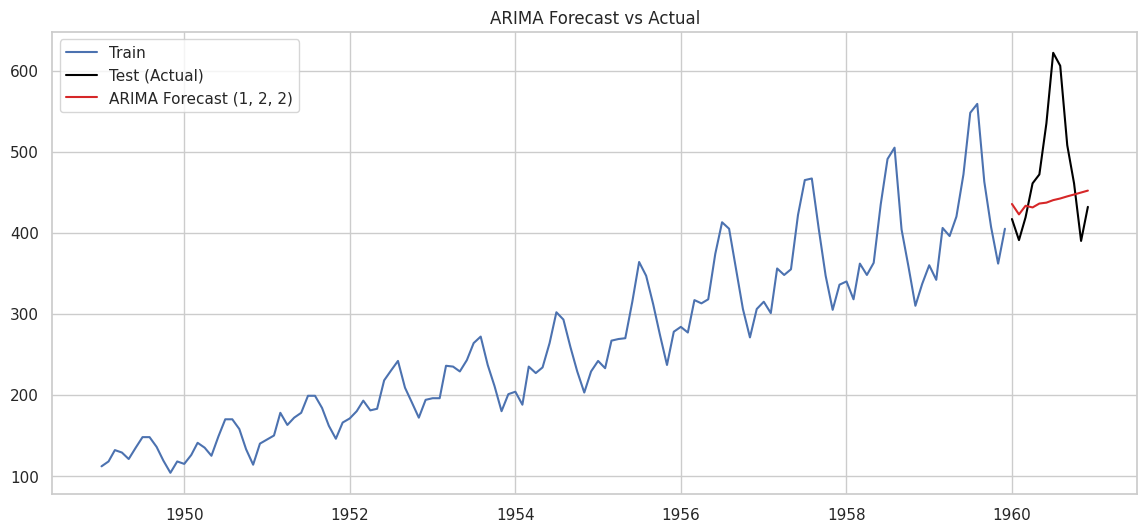

In [18]:
# 5) Forecast next 12 periods
arima_forecast = best_arima_model.forecast(steps=12)
arima_forecast.index = test.index

# 6) Evaluate using RMSE or MAE
arima_mae = mean_absolute_error(test['Passengers'], arima_forecast)
arima_mse = mean_squared_error(test['Passengers'], arima_forecast)
arima_rmse = np.sqrt(arima_mse)

print(f'ARIMA MAE: {arima_mae:.3f}')
print(f'ARIMA RMSE: {arima_rmse:.3f}')

plt.figure(figsize=(14, 6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test (Actual)', color='black')
plt.plot(arima_forecast.index, arima_forecast, label=f'ARIMA Forecast {best_order}', color='tab:red')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.show()

### ARIMA Interpretation
- **p**: Number of autoregressive lags (how many previous observations are used).
- **d**: Number of differencing operations to make the series stationary.
- **q**: Number of moving-average lags (how many previous forecast errors are used).

## Assignment 2: SARIMA Modeling

In [19]:
# 1) Identify seasonal period
seasonal_period = 12  # monthly data with yearly seasonality
print(f'Seasonal period selected: {seasonal_period}')

Seasonal period selected: 12


In [20]:
# 2) Fit SARIMA model with compact AIC search
best_sarima_aic = np.inf
best_sarima_order = None
best_sarima_seasonal_order = None
best_sarima_model = None

for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 3):
            for Q in range(0, 3):
                order = (p, d, q)
                seasonal_order = (P, 1, Q, seasonal_period)
                try:
                    model = SARIMAX(
                        train['Passengers'],
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    fitted = model.fit(disp=False)
                    if fitted.aic < best_sarima_aic:
                        best_sarima_aic = fitted.aic
                        best_sarima_order = order
                        best_sarima_seasonal_order = seasonal_order
                        best_sarima_model = fitted
                except Exception:
                    continue

print(f'Best SARIMA order: {best_sarima_order}')
print(f'Best seasonal order: {best_sarima_seasonal_order}')
print(f'Best SARIMA AIC: {best_sarima_aic:.2f}')

Best SARIMA order: (0, 2, 2)
Best seasonal order: (1, 1, 2, 12)
Best SARIMA AIC: 708.22


In [21]:
# 3) Compare ARIMA vs SARIMA performance
sarima_forecast = best_sarima_model.forecast(steps=12)
sarima_forecast.index = test.index

sarima_mae = mean_absolute_error(test['Passengers'], sarima_forecast)
sarima_mse = mean_squared_error(test['Passengers'], sarima_forecast)
sarima_rmse = np.sqrt(sarima_mse)

metrics = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA'],
    'MAE': [arima_mae, sarima_mae],
    'RMSE': [arima_rmse, sarima_rmse]
}).sort_values('RMSE')

metrics

,Model,MAE,RMSE
1,SARIMA,19.311072,24.747267
0,ARIMA,60.828991,82.272182


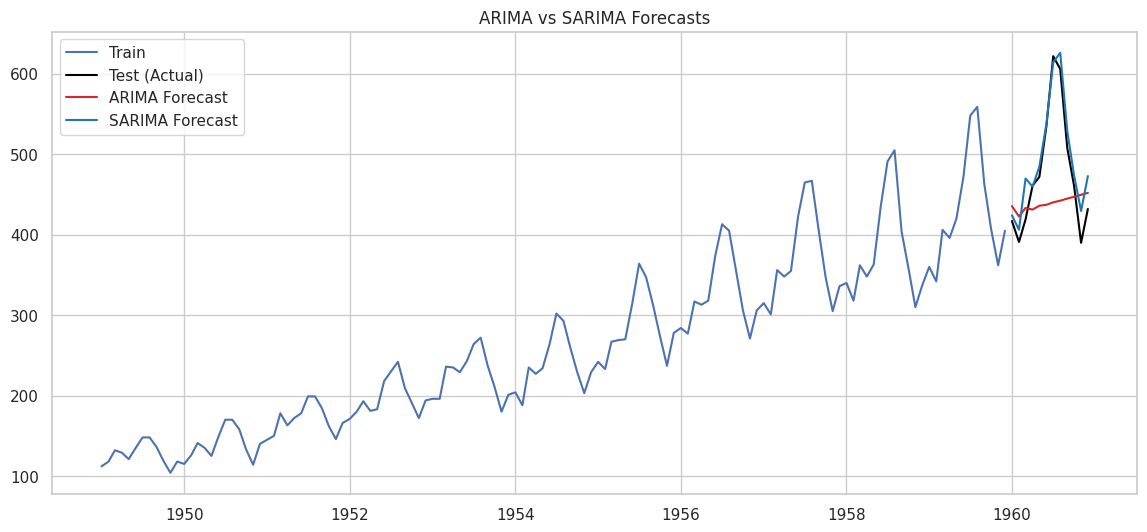

In [22]:
# 4) Plot forecasts together
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test (Actual)', color='black')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='tab:red')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', color='tab:blue')
plt.title('ARIMA vs SARIMA Forecasts')
plt.legend()
plt.show()

### SARIMA Explanation
SARIMA usually performs better when data contains clear seasonality because it models both non-seasonal patterns `(p, d, q)` and seasonal patterns `(P, D, Q, s)`.

If SARIMA performs worse, common causes are overfitting from too many parameters, weak seasonality, or unstable parameter estimates.

## Assignment 3: Prophet Forecasting

In [23]:
# 1) Convert dataset to Prophet format
prophet_df = df.reset_index().rename(columns={'Month': 'ds', 'Passengers': 'y'})

prophet_train = prophet_df.iloc[:-12].copy()
prophet_test = prophet_df.iloc[-12:].copy()

prophet_df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [24]:
# 2) Fit Prophet model
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
prophet_model.fit(prophet_train)

Importing plotly failed. Interactive plots will not work.
00:34:05 - cmdstanpy - INFO - Chain [1] start processing
00:34:05 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
# 3) Forecast next 12 periods
future = prophet_model.make_future_dataframe(periods=12, freq='MS')
prophet_forecast_full = prophet_model.predict(future)

prophet_pred = prophet_forecast_full[['ds', 'yhat']].tail(12).copy()
prophet_pred = prophet_pred.set_index('ds')['yhat']

prophet_mae = mean_absolute_error(test['Passengers'], prophet_pred)
prophet_mse = mean_squared_error(test['Passengers'], prophet_pred)
prophet_rmse = np.sqrt(prophet_mse)

print(f'Prophet MAE: {prophet_mae:.3f}')
print(f'Prophet RMSE: {prophet_rmse:.3f}')

Prophet MAE: 33.435
Prophet RMSE: 43.068


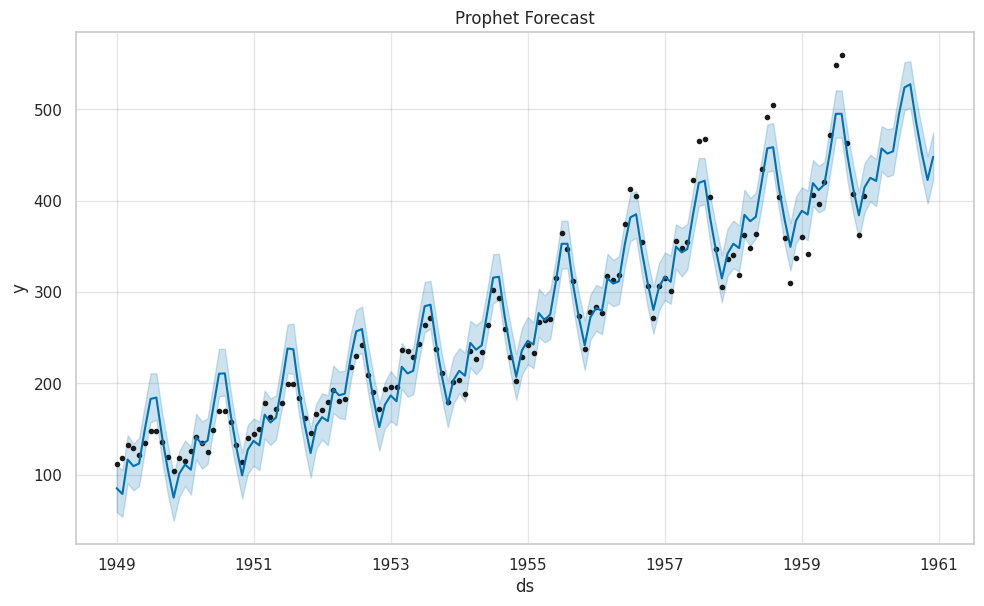

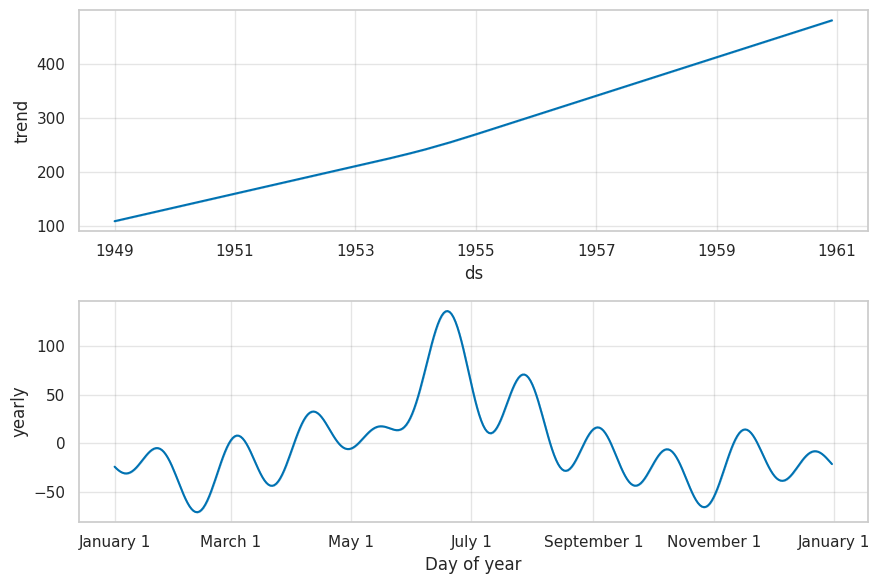

In [26]:
# 4) Plot Forecast, Trend component, and Seasonality component
fig1 = prophet_model.plot(prophet_forecast_full)
plt.title('Prophet Forecast')
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast_full)
plt.show()

In [27]:
# 5) Final model comparison
comparison = pd.DataFrame({
    'Model': ['ARIMA', 'SARIMA', 'Prophet'],
    'MAE': [arima_mae, sarima_mae, prophet_mae],
    'RMSE': [arima_rmse, sarima_rmse, prophet_rmse]
}).sort_values('RMSE')

comparison

,Model,MAE,RMSE
1,SARIMA,19.311072,24.747267
2,Prophet,33.434522,43.067854
0,ARIMA,60.828991,82.272182


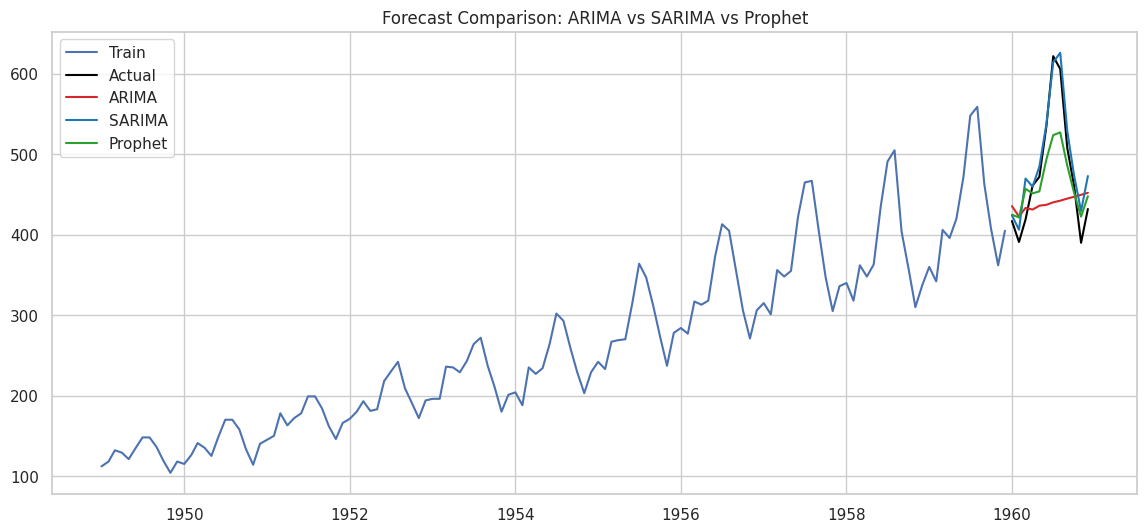

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Actual', color='black')
plt.plot(arima_forecast.index, arima_forecast, label='ARIMA', color='tab:red')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA', color='tab:blue')
plt.plot(prophet_pred.index, prophet_pred, label='Prophet', color='tab:green')
plt.title('Forecast Comparison: ARIMA vs SARIMA vs Prophet')
plt.legend()
plt.show()

#### Interpretation Section
1. The time series has a clear long-term upward trend, indicating growth in airline demand over years.
2. Strong yearly seasonality is present, with recurring peaks and troughs around similar months.
3. ADF test on original data usually indicates non-stationarity due to trend and changing mean level.
4. Differencing (`d`) helps remove trend and stabilize the series for ARIMA-based modeling.
5. In ARIMA, `p` captures dependency on previous observed values.
6. In ARIMA, `q` captures dependency on previous forecast errors.
7. SARIMA extends ARIMA by explicitly modeling seasonal autoregressive and moving-average dynamics.
8. Because this dataset has pronounced yearly seasonality (`s=12`), SARIMA often outperforms plain ARIMA.
9. Prophet is easier to implement and interpret because it directly decomposes trend and seasonality.
10. Prophet component plots provide intuitive diagnostic visuals that are useful for business communication.
11. The best-performing model should be selected using out-of-sample metrics (MAE/RMSE), not in-sample fit only.
12. AIC-based parameter search improves model selection, but final validation should rely on test-set forecasting accuracy.
13. Forecast uncertainty generally increases farther into the future; this should be considered in planning decisions.
14. All three methods can produce useful forecasts, but the right choice depends on seasonality strength, data volume, and interpretability needs.

#### Prophet vs SARIMA (Ease, Accuracy, Interpretability)
- **Ease of implementation**: Prophet is typically faster to set up with fewer manual tuning steps.
- **Accuracy**: SARIMA can be very accurate for stable seasonal patterns; Prophet can be competitive, especially with trend changes.
- **Interpretability**: Prophet has a practical edge via component decomposition plots; SARIMA is more statistical but less visual by default.